# Model Testing Notebook

Imports

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, Sequential
from keras.utils import image_dataset_from_directory

# model building imports
from keras import Model, Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, RandAugment, GlobalAveragePooling2D, GlobalMaxPool2D, Dropout
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score

#Model Class
from keras import Model

I0000 00:00:1776077372.295706  102948 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776077372.325184  102948 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Import data sample and split

In [21]:
train_sample_df, val_sample_df = image_dataset_from_directory(
    "wikiart_sample",
    label_mode= "categorical",
    image_size=(512,512),
    seed=42,
    interpolation="bilinear",
    batch_size=64,
    validation_split = 0.2,
    subset="both"
)

Found 2656 files belonging to 23 classes.
Using 2125 files for training.
Using 531 files for validation.


Import all data and split

In [2]:
train_df, val_df = image_dataset_from_directory(
    "wikiart_datasets",
    label_mode= "categorical",
    image_size=(512,512),
    seed=42,
    interpolation="bilinear",
    batch_size=32,
    validation_split = 0.2,
    subset="both"
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Using 2668 files for validation.


I0000 00:00:1776077381.967779  102948 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5146 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [3]:
input_shape= (512,512,3)

In [6]:
First_model = Sequential(
    layers= [Input(input_shape),
             Rescaling(scale= 1./255),

             #Primeira Convolutional
             Conv2D(filters=30, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),

            #Segunda Convolutional
             Conv2D(filters=60, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),

            #Terceira Convolutional
             Conv2D(filters=120, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),
              
            #Flatten e Dense layer
            Flatten(),

            #Primeiro Dense layer com mais neurons
            Dense(40, activation="relu"),

            #Second dense layer
            Dense(23, activation="softmax")
            
               ])


In [8]:
First_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 510, 510, 30)   │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 30)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 60)   │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 60)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 120)  │        64,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 120)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 461280)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40)             │    18,451,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │           943 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,534,203 (70.70 MB)

 Trainable params: 18,534,203 (70.70 MB)

 Non-trainable params: 0 (0.00 B)

Próxima parte temos de definar o que vai no Comlile, ou seja:

- A loss function
- O optimizer 
- As metrics

In [ ]:
optimizer = SGD(learning_rate=0.01, name="optimizer")
loss = CategoricalCrossentropy(name="loss")

In [ ]:
# metrics usadas para todos os modelos
categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [15]:
#Dar compile com o que acabamos de definir
First_model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [ ]:
#Defenir número de epoches 

epochs = 10


In [ ]:
#Dar fit do modelo de sample

First_model.fit(
    train_sample_df,
    validation_data=val_sample_df,
    epochs=epochs
)                            #Não é preciso meter batch_size porque já foi especificado quando importarmos os dados

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.0692 - auc: 0.5416 - f1_score: 0.0229 - loss: 3.1570 - val_accuracy: 0.0395 - val_auc: 0.5385 - val_f1_score: 0.0150 - val_loss: 3.1414
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.0795 - auc: 0.5751 - f1_score: 0.0288 - loss: 3.0977 - val_accuracy: 0.1036 - val_auc: 0.5871 - val_f1_score: 0.0256 - val_loss: 3.0853
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.1021 - auc: 0.5980 - f1_score: 0.0362 - loss: 3.0681 - val_accuracy: 0.0603 - val_auc: 0.5467 - val_f1_score: 0.0183 - val_loss: 3.3935
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.1172 - auc: 0.6211 - f1_score: 0.0318 - loss: 3.0340 - val_accuracy: 0.1168 - val_auc: 0.6152 - val_f1_score: 0.0325 - val_loss: 3.0541
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.1529 - auc: 0.6492 - f1_score: 0.0405 - loss: 2.9779 - val_accuracy: 0.0942 - val_auc: 0.6362 - val_f1_score: 0.0251 - val_loss: 3.032

Dar plot das metrics

In [12]:
def plot_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train')
    axes[0, 0].plot(history.history['val_loss'], label='Val')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()

    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train')
    axes[0, 1].plot(history.history['val_accuracy'], label='Val')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()

    # F1 Score
    axes[1, 0].plot(history.history['f1_score'], label='Train')
    axes[1, 0].plot(history.history['val_f1_score'], label='Val')
    axes[1, 0].set_title('F1 Score')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].legend()

    # AUC
    axes[1, 1].plot(history.history['auc'], label='Train')
    axes[1, 1].plot(history.history['val_auc'], label='Val')
    axes[1, 1].set_title('AUC')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_history(First_model)

Primeiro modelo com todos os dados

In [23]:
AD_first_model =First_model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)         

Epoch 1/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.2254 - auc: 0.7462 - f1_score: 0.1151 - loss: 2.7100 - val_accuracy: 0.2095 - val_auc: 0.7509 - val_f1_score: 0.1265 - val_loss: 2.7042
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 483s 3s/step - accuracy: 0.2567 - auc: 0.7833 - f1_score: 0.1663 - loss: 2.5736 - val_accuracy: 0.2549 - val_auc: 0.7760 - val_f1_score: 0.1660 - val_loss: 2.6005
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - accuracy: 0.2823 - auc: 0.8083 - f1_score: 0.2029 - loss: 2.4657 - val_accuracy: 0.2178 - val_auc: 0.7829 - val_f1_score: 0.1435 - val_loss: 2.6188
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.3033 - auc: 0.8273 - f1_score: 0.2314 - loss: 2.3753 - val_accuracy: 0.2676 - val_auc: 0.8070 - val_f1_score: 0.1998 - val_loss: 2.4915
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.3343 - auc: 0.8433 - f1_score: 0.2688 - loss: 2.2821 - val_accuracy: 0.2702 - val_auc: 0.7997 - val_f1_score: 0.2084 - va

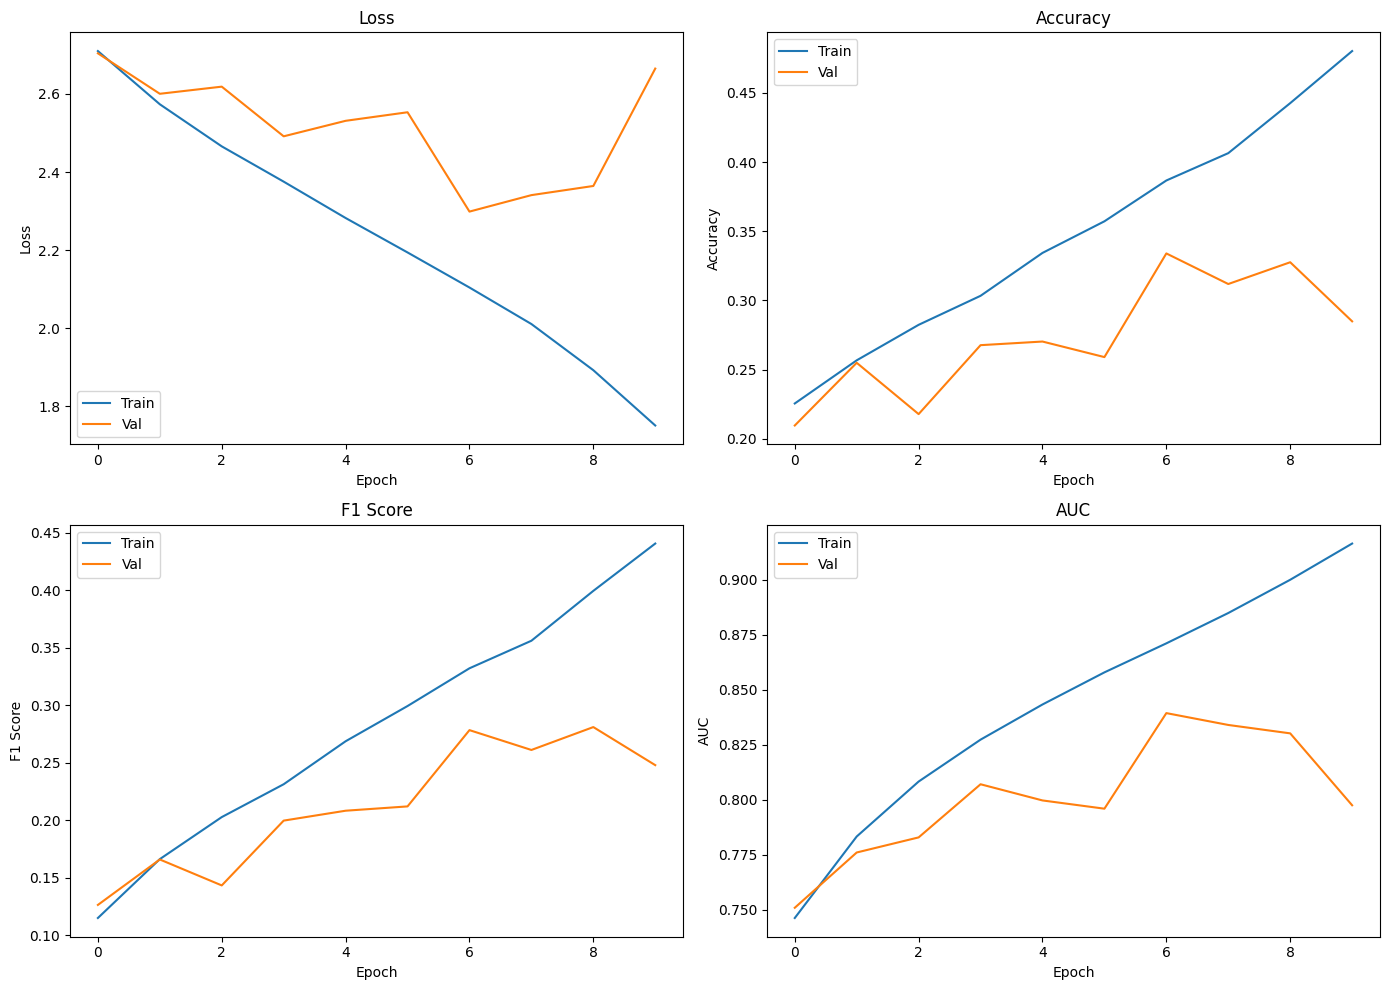

In [ ]:
plot_history(AD_first_model)

In [25]:
print("GPU disponível:", tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU disponível: False


# Pre-Trained Models

### ResNet

In [8]:
from keras.applications import ResNet50


O Primeiro modelo que vou testar é um ResNet 50, com dois dense layers, e tendo os weights dos modelos pre-trainded freaze

In [17]:
class my_ResNet50_1(Model):
    """
    Pre_trainned ResNet50

    """
    #Initialization
    def __init__(self):
        super().__init__(name="My_ResNet50_1")

        self.n_classes = 23
        self.Rescaling = Rescaling( scale= 1/127.5, offset=-1)
        self.base_model = ResNet50(include_top=False, weights="imagenet", classes=23)
        self.base_model.trainable = False  #Dar freaze ao modelo
        self.Flatten_layer = GlobalMaxPool2D() #Usei GlobalMaxPool2D em vez do Flatten, porque o flatten gera um vetor muito longo
        self.Dense_1 = Dense(120, activation="relu")
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)
        x = self.base_model(x, training = False) #Temos de ter training igual a false, mesmo tendo congelado o modelo em cima, porque                                    
        x = self.Flatten_layer(x)                                       #os batchnormalization layers continuam a treinar e neste primeiro teste não queremos isso
        x = self.Dense_1(x)
        x = self.Dense_2(x)

        return x


In [18]:
first_resnet50 = my_ResNet50_1()
inputs = Input(shape=input_shape)
_ = first_resnet50.call(inputs)
first_resnet50.summary()

Model: "My_ResNet50_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_2          │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │       245,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         2,783 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,836,375 (90.93 MB)

 Trainable params: 248,663 (971.34 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
epochs = 10

optimizer = SGD(learning_rate=0.002, name="optimizer")
loss = CategoricalCrossentropy(name="loss")


categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [11]:
#Dar complile do modelo
first_resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [12]:
first_resnet50_results= first_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/10


I0000 00:00:1776005806.349929   29133 service.cc:153] XLA service 0x7429ec067870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776005806.349959   29133 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1776005806.498530   29133 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776005807.407684   29133 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1776005807.443507   29133 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10962__.198
W0000 00:00:1776005820.878057   29133 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.53GiB (rounded to 4865688320)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async

166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.1083 - auc: 0.6075 - f1_score: 0.0717 - loss: 4.0049

I0000 00:00:1776005889.746393   29132 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10962__.198
W0000 00:00:1776005901.888598   29132 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.90GiB (rounded to 4190405376)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776005901.888758   29132 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776005901.888769   29132 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 98, Chunks in use: 97. 24.5KiB allocated for chunks. 24.2KiB in use in bin. 9.5KiB client-requested in use in bin.
I0000 00:00:1776005901.888781   29132 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 41, Chunks in use: 41. 20.5KiB allocated for chunks. 20.5KiB in use in bin. 20.5KiB client-requested in use in bin.
I0

167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.1085 - auc: 0.6078 - f1_score: 0.0718 - loss: 4.0003

I0000 00:00:1776005928.230976   31048 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 4 bytes spill stores, 4 bytes spill loads

W0000 00:00:1776005940.266372   29133 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.75GiB (rounded to 4021584640)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776005940.266415   29133 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776005940.266418   29133 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 105, Chunks in use: 105. 26.2KiB allocated for chunks. 26.2KiB in use in bin. 9.5KiB client-requested in use in bin.
I0000 00:00:1776005940.266422   29133 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 41, Chunks in use: 41. 20.5KiB allocated 

167/167 ━━━━━━━━━━━━━━━━━━━━ 144s 699ms/step - accuracy: 0.1371 - auc: 0.6578 - f1_score: 0.0865 - loss: 3.2231 - val_accuracy: 0.1683 - val_auc: 0.7081 - val_f1_score: 0.0975 - val_loss: 2.8700
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 72s 433ms/step - accuracy: 0.1859 - auc: 0.7350 - f1_score: 0.1234 - loss: 2.7838 - val_accuracy: 0.1825 - val_auc: 0.7284 - val_f1_score: 0.0970 - val_loss: 2.8147
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 72s 430ms/step - accuracy: 0.2058 - auc: 0.7613 - f1_score: 0.1407 - loss: 2.6909 - val_accuracy: 0.2095 - val_auc: 0.7662 - val_f1_score: 0.1477 - val_loss: 2.6677
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 72s 431ms/step - accuracy: 0.2234 - auc: 0.7781 - f1_score: 0.1579 - loss: 2.6218 - val_accuracy: 0.1844 - val_auc: 0.7642 - val_f1_score: 0.1410 - val_loss: 2.7131
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 72s 434ms/step - accuracy: 0.2367 - auc: 0.7901 - f1_score: 0.1743 - loss: 2.5713 - val_accuracy: 0.2350 - val_auc: 0.7850 - val_f1_score: 0.1627 - va

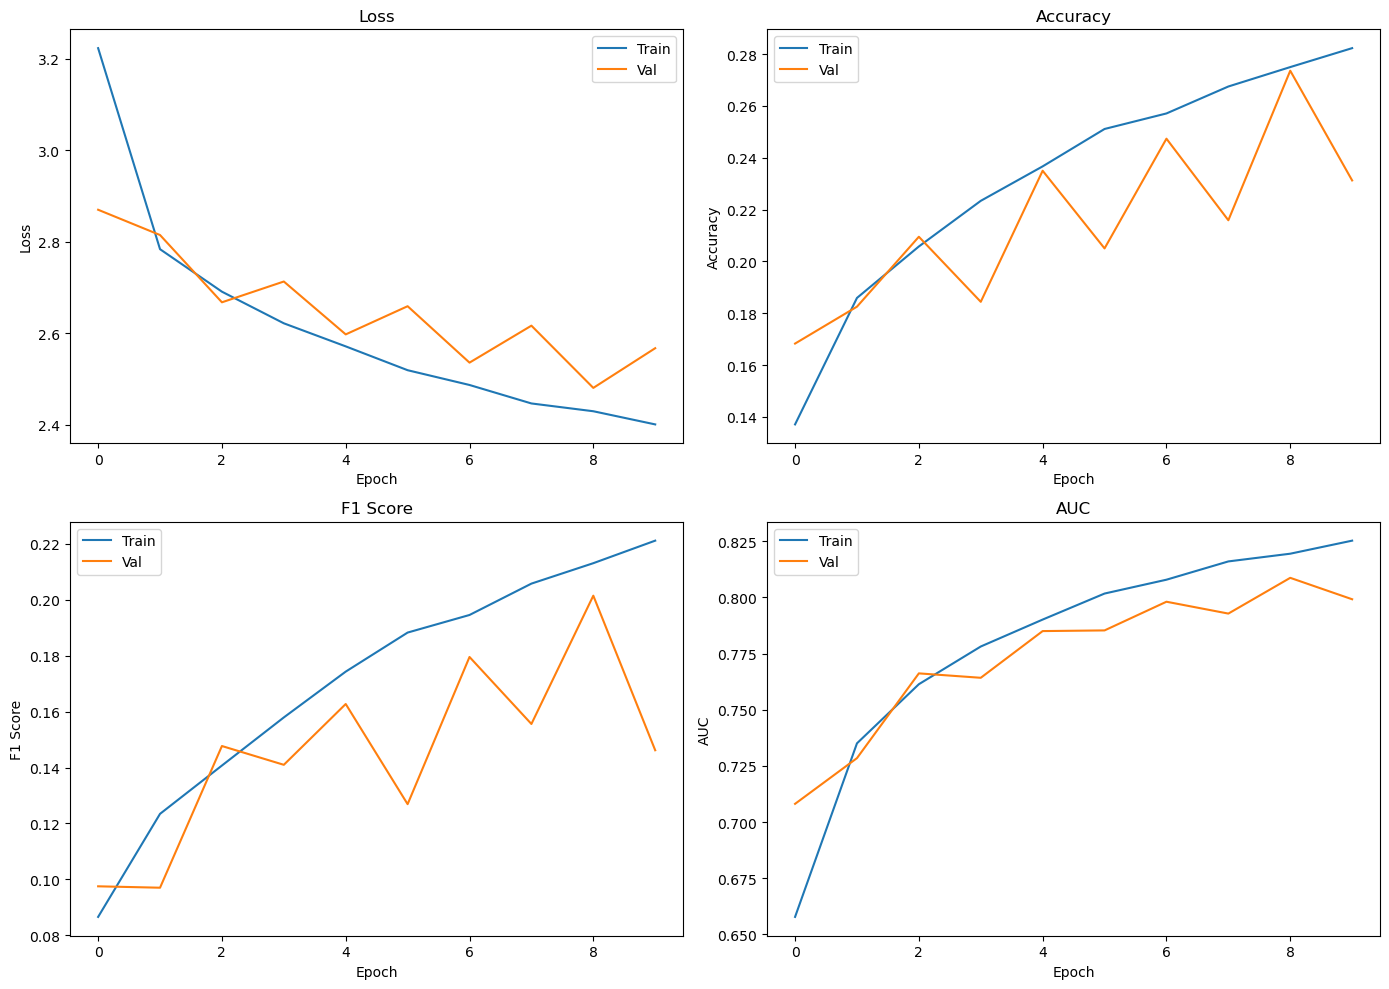

In [13]:
plot_history(first_resnet50_results)

For a first test of ResNet we didn't get the best scores and still got overfiting so we will try to build another model (still with the original ResNet frozen), but with some alterations: (aqui também diminui o batch size de 64 para 32)


- Drop_out (for overfitting)
- Initial Random augmentation (for overfitting) 
- Increasing Learning Rate from 0.002 to 0.004 (trying to increase performance)  
- Increase the number of epoches from 10 to 40 (to see if we have some convergence)

In [5]:
class my_ResNet50_2(Model):
    """
    Pre_trainned ResNet50 + Drop_out + initial random augmentation

    """
    #Initialization
    def __init__(self):
        super().__init__(name="My_ResNet50_2")

        self.n_classes = 23
        self.Rescaling = Rescaling( scale= 1/127.5, offset=-1)
        self.RandAugment = RandAugment(value_range= (-1,1), num_ops = 3, seed=42)
        self.base_model = ResNet50(include_top=False, weights="imagenet", classes=23)
        self.base_model.trainable = False  #Dar freaze ao modelo
        self.Globalmax_layer = GlobalMaxPool2D() #Usei GlobalMaxPool2D em vez do Flatten, porque o flatten gera um vetor muito longo
        self.Dense_1 = Dense(120, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)
        x = self.RandAugment(x)
        x = self.base_model(x, training = False) #Temos de ter training igual a false, mesmo tendo congelado o modelo em cima, porque                                    
        x = self.Globalmax_layer(x)                                       #os batchnormalization layers continuam a treinar e neste primeiro teste não queremos isso
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [23]:
second_resnet50 = my_ResNet50_2()
inputs = Input(shape=input_shape)
_ = second_resnet50.call(inputs)
second_resnet50.summary()

Model: "My_ResNet50_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rand_augment (RandAugment)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_3          │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │       245,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │         2,783 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,836,375 (90.93 MB)

 Trainable params: 248,663 (971.34 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
epochs = 40

optimizer = SGD(learning_rate=0.004, name="optimizer")
loss = CategoricalCrossentropy(name="loss")


categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [25]:
second_resnet50.compile(loss=loss, optimizer=optimizer, metrics= metrics)

In [26]:
second_resnet50_results= second_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40


W0000 00:00:1776014671.690627   29128 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.29GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


334/334 ━━━━━━━━━━━━━━━━━━━━ 304s 876ms/step - accuracy: 0.0821 - auc: 0.5395 - f1_score: 0.0283 - loss: 3.2800 - val_accuracy: 0.1091 - val_auc: 0.5777 - val_f1_score: 0.0209 - val_loss: 3.1212
Epoch 2/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 284s 852ms/step - accuracy: 0.0893 - auc: 0.5827 - f1_score: 0.0303 - loss: 3.0961 - val_accuracy: 0.1057 - val_auc: 0.5866 - val_f1_score: 0.0349 - val_loss: 3.1211
Epoch 3/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 283s 847ms/step - accuracy: 0.1090 - auc: 0.6105 - f1_score: 0.0403 - loss: 3.0543 - val_accuracy: 0.0915 - val_auc: 0.6269 - val_f1_score: 0.0306 - val_loss: 3.0494
Epoch 4/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 285s 854ms/step - accuracy: 0.1168 - auc: 0.6373 - f1_score: 0.0455 - loss: 3.0204 - val_accuracy: 0.1072 - val_auc: 0.6397 - val_f1_score: 0.0345 - val_loss: 3.0256
Epoch 5/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 284s 851ms/step - accuracy: 0.1211 - auc: 0.6572 - f1_score: 0.0481 - loss: 2.9734 - val_accuracy: 0.1271 - val_auc: 0.6550 - val_f1_score: 0.0414 

Com estas alterações o modelo demorou bem mais (também foram mais epochs), mas ao contrário do esperado a performance diminuiu um bocado, mesmo não estando a dar tanto overfit. Ter aumentado o Learning Rate provavelmente foi uma má opção pois o modelo não conseguiu convergir e a performance piorou - > próximo passo treinar este mesmo modelo mas com learning rate mais baixo, para perseber se foi este a causa do problema

- Reduzi Learning rate de 0.004 para 0.001

In [9]:
second_2_Resnet50 = my_ResNet50_2()

In [10]:
epochs = 40
loss = CategoricalCrossentropy(name="loss")
optimizer = SGD(learning_rate=0.001, name="optimizer")


categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [11]:
second_2_Resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [13]:
second_2_Resnet50_results = second_2_Resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40


I0000 00:00:1776078481.338460  103189 cuda_dnn.cc:461] Loaded cuDNN version 91700


334/334 ━━━━━━━━━━━━━━━━━━━━ 305s 874ms/step - accuracy: 0.1057 - auc: 0.6295 - f1_score: 0.0590 - loss: 3.1859 - val_accuracy: 0.1169 - val_auc: 0.6619 - val_f1_score: 0.0580 - val_loss: 3.0059
Epoch 2/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 286s 856ms/step - accuracy: 0.1333 - auc: 0.6805 - f1_score: 0.0683 - loss: 2.9464 - val_accuracy: 0.1199 - val_auc: 0.6754 - val_f1_score: 0.0417 - val_loss: 2.9870
Epoch 3/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 283s 849ms/step - accuracy: 0.1519 - auc: 0.6998 - f1_score: 0.0797 - loss: 2.8941 - val_accuracy: 0.1364 - val_auc: 0.6955 - val_f1_score: 0.0642 - val_loss: 2.9062
Epoch 4/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 285s 853ms/step - accuracy: 0.1538 - auc: 0.7089 - f1_score: 0.0857 - loss: 2.8667 - val_accuracy: 0.1525 - val_auc: 0.6989 - val_f1_score: 0.0666 - val_loss: 2.8985
Epoch 5/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 284s 850ms/step - accuracy: 0.1729 - auc: 0.7187 - f1_score: 0.1024 - loss: 2.8330 - val_accuracy: 0.1657 - val_auc: 0.7202 - val_f1_score: 0.0872 

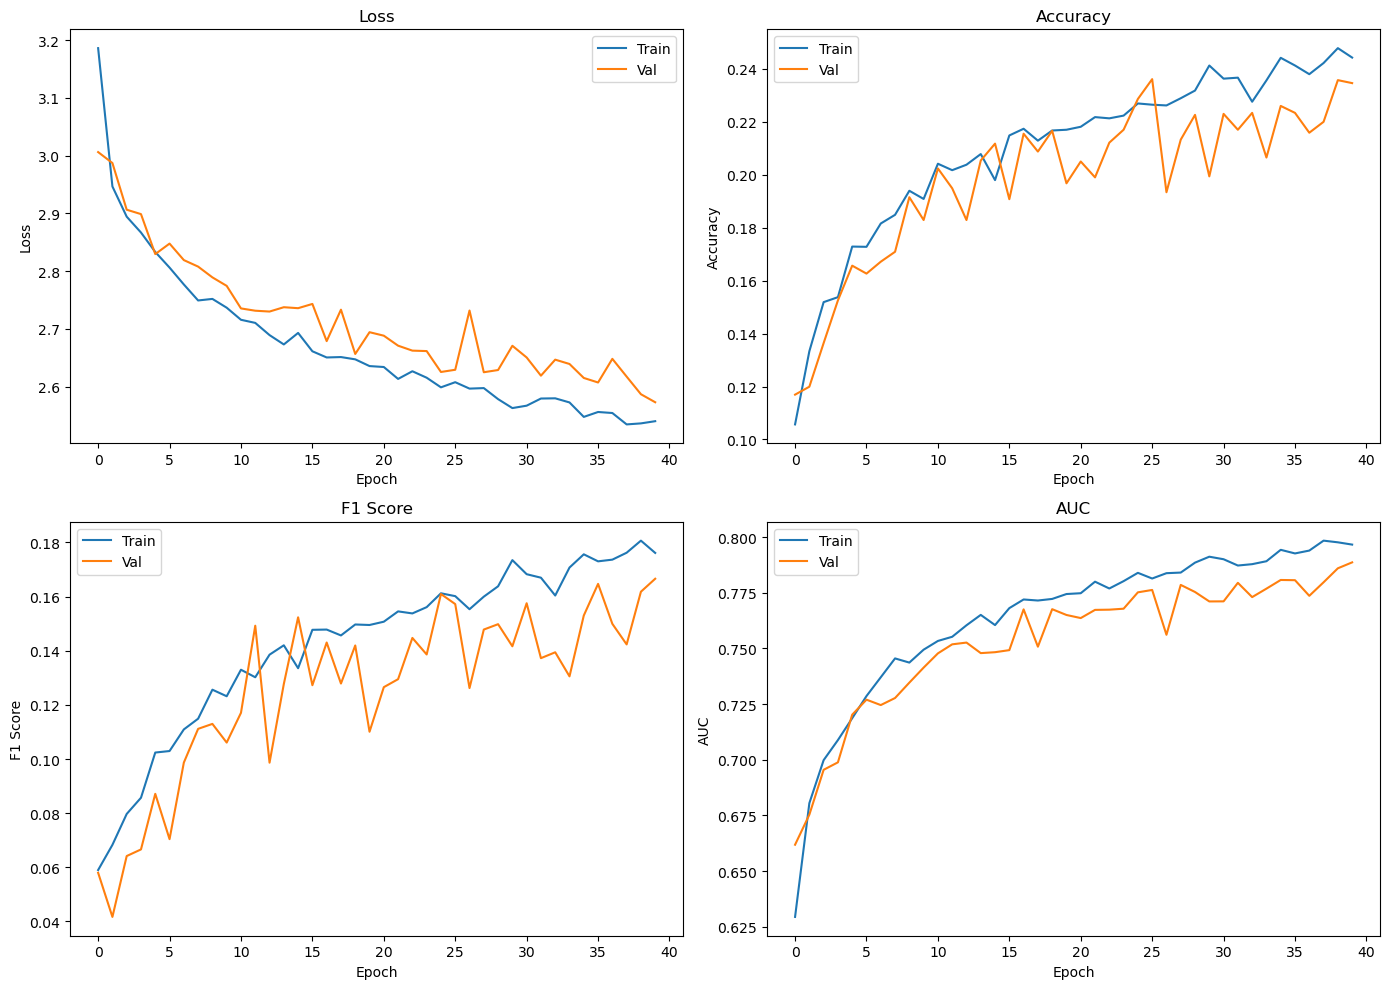

In [14]:
plot_history(second_2_Resnet50_results)

vendo os resultados o modelo não teve tantos saltos drásticos como o anterior o que era esperado tendo em conta a descida de learning rate, optivemos um score melhor mas não muito significativo a meio ver. O overfitting continua controlado o que é bom, mas pode ser por causa de augmentations ou do drop out que o modelo não está a ter tão boas performances como antes de os colocar.

- adicionar augmentations que façam mais sentido para tentar melhorar a performance mas controlando na mesma o overfitting

Augmentations que quero adicionar:

- Horizontal flipping
- Random Rotation (small)
- Random Zoom
- Random Brightness / Contrast